In [ ]:
import sys
sys.path.append("/content")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp import MLP
from _Adaline import Adaline
import random

In [ ]:
data = pd.read_csv("mess_dataset_5000.csv")

X = data.drop(columns=["student_id","mess_duration"]).values
y = data["mess_duration"].values.reshape(-1,1)
X = (X - X.mean(axis=0)) / X.std(axis=0)
np.random.seed(42)
random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))

train_idx = indices[:split]
val_idx = indices[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]


6.3.1 Depth

In [ ]:
input_dim = X.shape[1]
output_dim = 1
architectures = {
    "1_layer": [input_dim, 64, output_dim],
    "2_layers": [input_dim, 64, 64, output_dim],
    "3_layers": [input_dim, 64, 64, 64, output_dim],
    "4_layers": [input_dim, 64, 64, 64, 64, output_dim]
}


Training: 1_layer


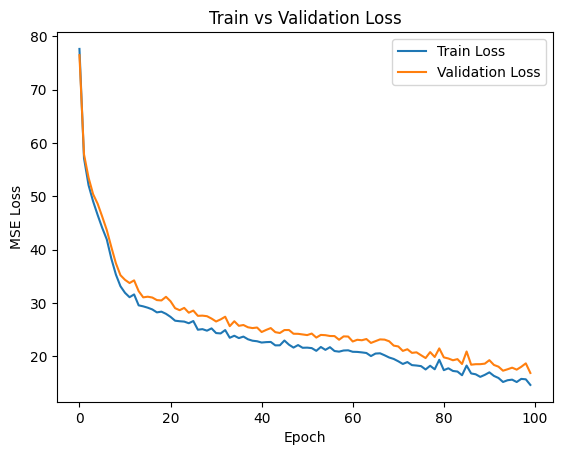

Validation MSE: 16.868352612246763
Error Gap: 2.238713663401281
Epoch time: 0.014297580718994141
Training: 2_layers


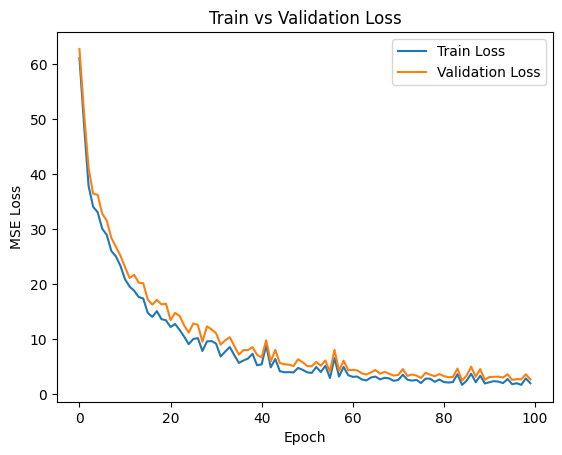

Validation MSE: 2.744754457974679
Error Gap: 0.7054652381266697
Epoch time: 0.028921682834625245
Training: 3_layers


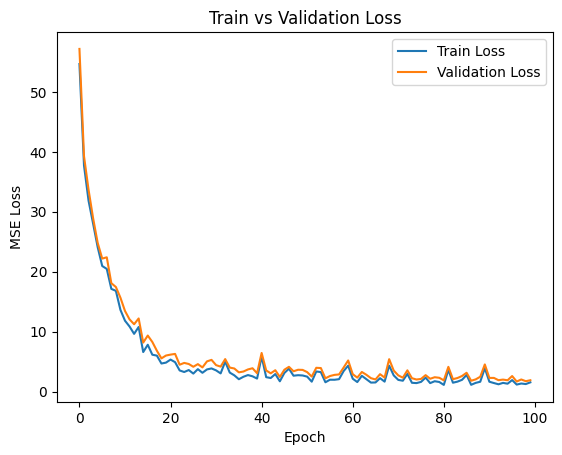

Validation MSE: 1.9122621915288516
Error Gap: 0.3486467484122757
Epoch time: 0.05159450769424438
Training: 4_layers


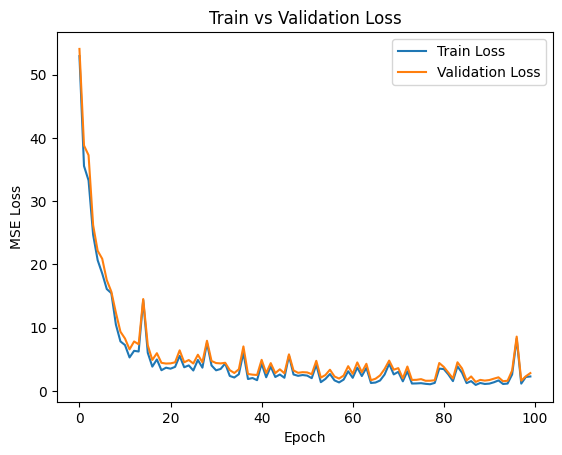

Validation MSE: 2.821479945473315
Error Gap: 0.5346924690130761
Epoch time: 0.05621068716049194


In [ ]:
import time
import matplotlib.pyplot as plt


results = {}

for name, layers in architectures.items():

    print("Training:", name)

    activations = ["relu"]*(len(layers)-2) + ["linear"]
    np.random.seed(42)
    model = MLP(
        layer_sizes=layers,
        activations=activations,
        loss="mse",
        optimizer="adam",
        batch_size = 64,
        learning_rate=0.01,
        weight_init="he"
    )
    start = time.time()

    history = model.fit(X_train, y_train, X_val, y_val, 100)

    end = time.time()

    epoch_time = (end - start)/100


    # Loss Curves

    plt.figure()

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Train vs Validation Loss")

    plt.legend()
    plt.show()

    y_pred,_ = model.forward(X_val)
    val_mse = model.loss(y_val, y_pred[-1])
    print("Validation MSE:", val_mse)
    results[name] = {
        "history": history,
        "epoch_time": epoch_time,
        "mse": val_mse
    }
    print("Error Gap:", np.abs(history["train_loss"][-1]-history["val_loss"][-1]))
    print("Epoch time:", epoch_time)

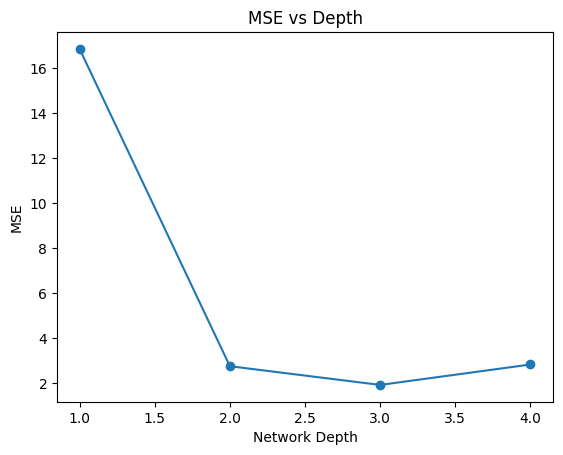

In [ ]:
depths = [1,2,3,4]
accuracies = [results["1_layer"]["mse"],
              results["2_layers"]["mse"],
              results["3_layers"]["mse"],
              results["4_layers"]["mse"]]

plt.plot(depths, accuracies, marker='o')
plt.xlabel("Network Depth")
plt.ylabel("MSE")
plt.title("MSE vs Depth")
plt.show()

1 Hidden Layer: [input, 64, output]

Observations

Training and validation losses decrease initially but remain relatively high.

The model does not capture the complexity of the data well.

The large train–validation gap suggests weak generalization.

so,The network underfits the data due to insufficient model capacity.

2 Hidden Layers: [input, 64, 64, output]

Observations

There is a significant drop in validation error compared to the 1-layer model.

Training and validation curves follow a similar trend, indicating stable learning.

The error gap is much smaller, suggesting better generalization.

Therefore,Adding a second hidden layer greatly improves the model's ability to capture nonlinear patterns in the data.

3 Hidden Layers: [input, 64, 64, 64, output]

Observations

Validation loss decreases slightly compared to the 2-layer network.

The training and validation curves remain close, indicating good generalization.

However, the improvement in error is relatively small compared to the additional computational cost.

Although performance improves slightly, the training time nearly doubles, suggesting diminishing returns from increasing depth.

4 Hidden Layers: [input, 64, 64, 64, 64, output]

Observations

Validation error increases compared to the 3-layer model.

The validation curve shows slightly more fluctuations.

Increasing depth beyond three layers does not improve performance.

Therefore,Adding more layers leads to diminishing returns and slightly worse generalization.

6.3.2 Width

In [ ]:
# Widths to test
widths = [8,16,32,64,128,256]

param_counts = []
val_mses = []
for w in widths:

    layers = [input_dim, w, w, output_dim]

    activations = ["relu","relu","linear"]
    np.random.seed(42)
    model = MLP(
        layer_sizes=layers,
        activations=activations,
        loss="mse",
        optimizer="adam",
        batch_size=64,
        learning_rate=0.01,
        weight_init="he"
    )

    history = model.fit(X_train, y_train, X_val, y_val, 100)

    preds,_ = model.forward(X_val)
    val_mse = model.loss(y_val, preds[-1])

    # count parameters
    params = 0
    for i in range(len(layers)-1):
        params += layers[i]*layers[i+1] + layers[i+1]

    param_counts.append(params)
    val_mses.append(val_mse)
    print("Width:", w)
    print("Parameters:", params)
print("Validation MSE:", val_mses)

Width: 8
Parameters: 193
Width: 16
Parameters: 513
Width: 32
Parameters: 1537
Width: 64
Parameters: 5121
Width: 128
Parameters: 18433
Width: 256
Parameters: 69633
Validation MSE: [np.float64(32.32085592759246), np.float64(19.56199826238471), np.float64(5.610233267728374), np.float64(2.744754457974679), np.float64(1.7653732326015796), np.float64(1.2687249419920117)]


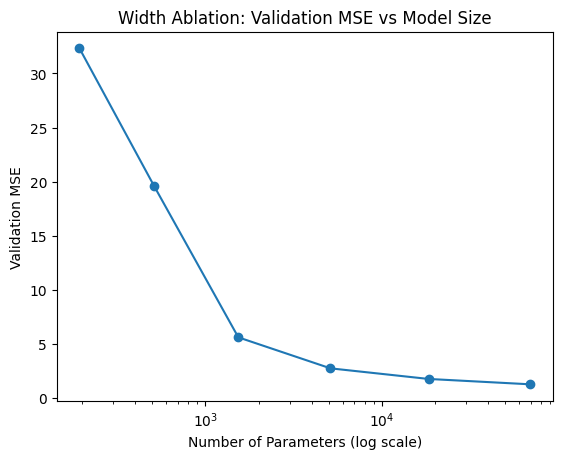

In [ ]:
plt.figure()

plt.plot(param_counts, val_mses, marker='o')

plt.xscale("log")

plt.xlabel("Number of Parameters (log scale)")
plt.ylabel("Validation MSE")

plt.title("Width Ablation: Validation MSE vs Model Size")

plt.show()

As the width increased, the validation MSE decreased, indicating that larger networks have greater capacity to learn complex patterns.

Very small models (width 8 and 16) showed high error, indicating underfitting due to insufficient capacity. Increasing the width to 32 and 64 neurons significantly improved performance by reducing the validation MSE.

Beyond 64 neurons, the improvement in performance became very small, while the number of parameters increased rapidly. For example, increasing width from 64 to 256 increases parameters from about 5K to nearly 70K, but produces only a small reduction in MSE.

Therefore, width = 64 provides the best balance between model performance and computational efficiency, achieving low error with a relatively small number of parameters

Width vs Depth Performance Relationship

Both width and depth increase the expressive power of a neural network, but they improve performance in different ways.

Increasing depth adds more layers, allowing the model to learn hierarchical and more complex feature representations. In the depth ablation experiment, performance improved when increasing layers from 1 to 2, but further increasing depth gave only small improvements while increasing training time.

Increasing width adds more neurons in each layer, allowing the network to learn more features at the same level. In the width ablation experiment, increasing width significantly reduced the error up to 64 neurons, but further increases produced only marginal improvements while greatly increasing the number of parameters.

Overall, both experiments show that moderate architectures work best. Extremely deep or extremely wide networks lead to diminishing returns in performance. The best trade-off in this study is achieved with a moderate depth (2 hidden layers) and moderate width (64 neurons), which provides strong performance while keeping the model size efficient.

Training with: sigmoid


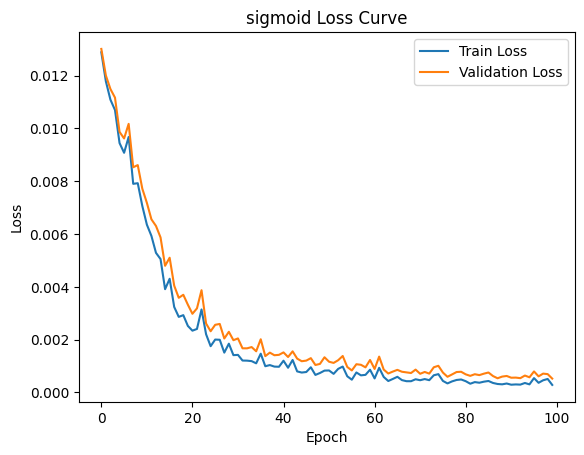

Gradient mean: -1.2527329001905254e-05
Gradient std: 0.0005235302759969871
Layer 1 gradient magnitude: 7.579948619256979e-05
Layer 2 gradient magnitude: 9.635754002048372e-05
Layer 3 gradient magnitude: 0.0028274448061156392
Training with: tanh


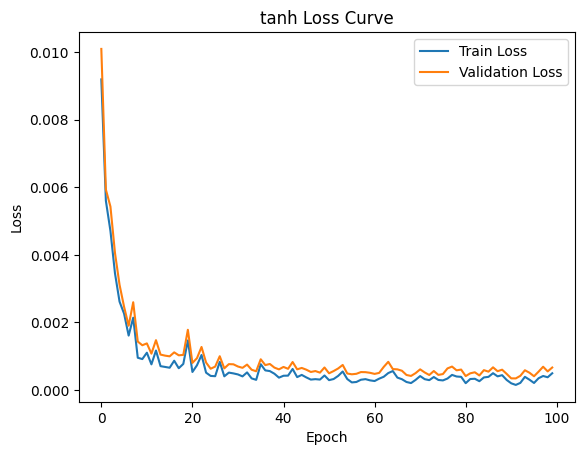

Gradient mean: -8.791054451832985e-06
Gradient std: 0.0009464076808214522
Layer 1 gradient magnitude: 0.00010575019639386308
Layer 2 gradient magnitude: 7.799137062107733e-05
Layer 3 gradient magnitude: 0.006903033319470558
Training with: relu


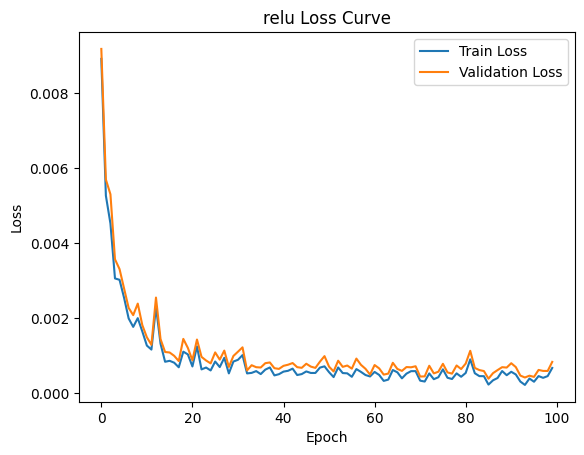

Gradient mean: 3.093474209769258e-05
Gradient std: 0.0008828084612266848
Dead neurons: 0
Layer 1 gradient magnitude: 0.00021562834362943729
Layer 2 gradient magnitude: 9.712769420678996e-05
Layer 3 gradient magnitude: 0.004596787807559127
Training with: leaky_relu


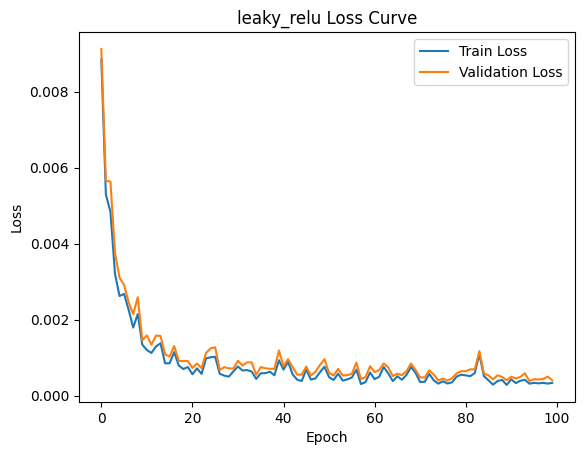

Gradient mean: -7.747136548617047e-06
Gradient std: 0.0002891642212607919
Layer 1 gradient magnitude: 0.0001265217871423102
Layer 2 gradient magnitude: 5.363076483594042e-05
Layer 3 gradient magnitude: 0.0016424858264217853


In [ ]:
layers = [input_dim, 64, 64, output_dim]
configs = {
    "sigmoid": ["sigmoid","sigmoid","sigmoid"],
    "tanh": ["tanh","tanh","sigmoid"],
    "relu": ["relu","relu","sigmoid"],
    "leaky_relu": ["leaky_relu","leaky_relu","sigmoid"]
}
results_act = {}

for name, acts in configs.items():

    print("Training with:", name)
    np.random.seed(42)
    model = MLP(
        layer_sizes=layers,
        activations=acts,
        loss="mse",
        optimizer="adam",
        batch_size = 64,
        learning_rate=0.01,
        weight_init="he"
    )
    y_min = y_train.min()
    y_max = y_train.max()

    y_train_scaled = (y_train - y_min) / (y_max - y_min)
    y_val_scaled = (y_val - y_min) / (y_max - y_min)
    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, 100)

    results_act[name] = {
        "history": history
    }
    grads_w,grads_b = model.backward(X_train, y_train_scaled)
    grad_values = []

    for g in grads_w:
      grad_values.append(g.flatten())

    grad_values = np.concatenate(grad_values)

    grad_mean = np.mean(grad_values)
    grad_std = np.std(grad_values)
    # plot loss curves
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(name + " Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    print("Gradient mean:", grad_mean)
    print("Gradient std:", grad_std)
    results_act[name]["grad_mean"] = grad_mean
    results_act[name]["grad_std"] = grad_std

    activations,_ = model.forward(X_train)

    hidden = activations[1]   # first hidden layer
    if name =="relu":
      dead_neurons = np.sum(np.all(hidden <= 0, axis=0))
      print("Dead neurons:", dead_neurons)
    else:
      dead_neurons = 0
    results_act[name]["dead_neurons"] = dead_neurons
    grad_magnitudes=[]
    for i,g in enumerate(grads_w):
      magnitude = np.mean(np.abs(g))
      print("Layer", i+1, "gradient magnitude:", magnitude)
      grad_magnitudes.append(magnitude)
      results_act[name]["grad_magnitudes"] = grad_magnitudes

Sigmoid shows slower convergence due to the vanishing gradient problem, as gradients in earlier layers become very small.

Tanh performs slightly better than sigmoid because it is zero-centered, which improves gradient flow.

ReLU converges faster and maintains larger gradients, leading to more efficient training with no dead neurons observed i.e neurons remained active in training.

Leaky ReLU provides stable training and avoids the dead neuron problem by allowing small gradients for negative inputs.

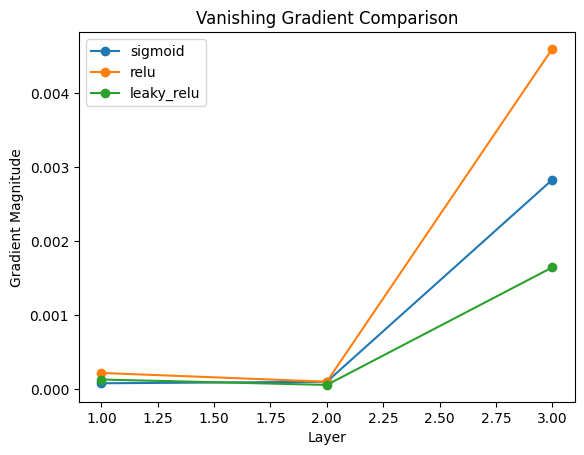

In [27]:
# Vanishing Gradient Plot
plt.figure()
for name in results_act:
    if name == "sigmoid" or name =="relu" or name =="leaky_relu":
        grads = results_act[name]["grad_magnitudes"]
        plt.plot(range(1,len(grads)+1), grads, marker='o', label=name)

plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing Gradient Comparison")
plt.legend()
plt.show()

The vanishing gradient phenomenon can be observed in the gradient magnitude plot across layers. For the sigmoid activation, the gradients in the earlier layers are very small compared to the deeper layer, indicating that gradients shrink as they propagate backward through the network. This makes weight updates in early layers very slow, which is the key characteristic of the vanishing gradient problem. In contrast, ReLU maintains larger gradient magnitudes, especially in deeper layers, which helps mitigate the vanishing gradient issue. Leaky ReLU also maintains stable gradients and avoids the zero-gradient problem of standard ReLU. Overall, ReLU and Leaky ReLU handle gradient flow better than sigmoid, making them more suitable for deeper neural networks.

In [ ]:
# =========================
# LOSS EXPERIMENT
# =========================

losses = ["mse", "mae", "huber"]
results = {}
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_val_scaled = (y_val - y_min) / (y_max - y_min)
for loss_name in losses:

    print("\nTraining with", loss_name.upper())
    np.random.seed(42)
    model = MLP(
        layer_sizes=[13,64,64,1],
        activations=["relu","relu","sigmoid"],
        loss=loss_name,
        learning_rate=0.001,
        optimizer="adam",
        batch_size=64,
        weight_init="he"
    )

    history = model.fit(
        X_train,
        y_train_scaled,
        X_val,
        y_val_scaled,
        epochs=100
    )

    val_pred,_ = model.forward(X_val)

    val_mse = np.mean((y_val_scaled - val_pred[-1])**2)

    results[loss_name] = val_mse

    '''plt.figure()
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.title(f"{loss_name.upper()} Loss")
    plt.legend()
    plt.show()

    print(loss_name.upper(), "Validation :", val_mse)'''

# =========================
# FINAL COMPARISON
# =========================

print("\nFinal Comparison (Validation MSE)")
for loss_name in losses:
    print(loss_name.upper(), ":", results[loss_name])


Training with MSE

Training with MAE

Training with HUBER

Final Comparison (Validation MSE)
MSE : 0.0006762625210121151
MAE : 0.005383840364436989
HUBER : 0.0007114531393391877


MSE achieved the lowest validation MSE (0.000676), showing the best performance since it strongly penalizes large errors.

Huber loss performed close to MSE (0.000711) and provides robustness to outliers by combining properties of MSE and MAE.

MAE had the highest validation MSE (0.00538) because it treats all errors equally and may converge slower.

Conclusion: MSE performed the best, while Huber is a good robust alternative, and MAE performed the worst for this task

In [ ]:
layer_sizes = [input_dim,64,64,output_dim]
activations = ["relu","relu","sigmoid"]

optimizers = [
    "sgd",
    "momentum",
    "adam",
    "nesterov",
    "adagrad",
    "rmsprop",
    "muon"
]

results = {}

for opt in optimizers:

    print("Training with:",opt)
    np.random.seed(42)
    model = MLP(
        layer_sizes,
        activations,
        loss="mse",
        learning_rate=0.0001,
        batch_size = 64,
        optimizer=opt
    )

    history = model.fit(X_train,y_train_scaled,X_val,y_val_scaled,epochs=100)

    results[opt] = history

Training with: sgd
Training with: momentum
Training with: adam
Training with: nesterov
Training with: adagrad
Training with: rmsprop
Training with: muon


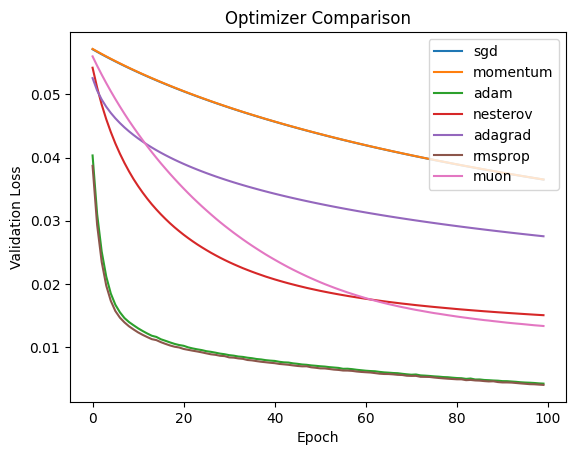

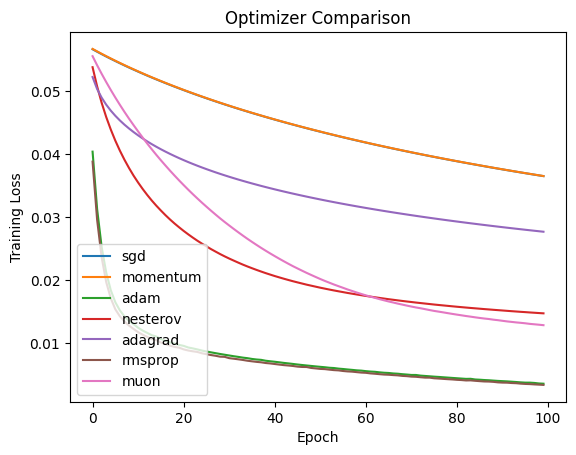

In [ ]:
for opt in results:

    plt.plot(results[opt]["val_loss"],label=opt)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()
for opt in results:
  plt.plot(results[opt]["train_loss"],label=opt)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

Adam and RMSProp converge the fastest and achieve the lowest training and validation loss, showing stable and efficient optimization.

SGD and Momentum converge more slowly, while Nesterov improves convergence compared to standard SGD.

AdaGrad and Muon show slower convergence and higher final loss compared to adaptive optimizers.

Conclusion: Adam and RMSProp perform best, providing faster convergence and lower final loss than the other optimizers for this learning rate.

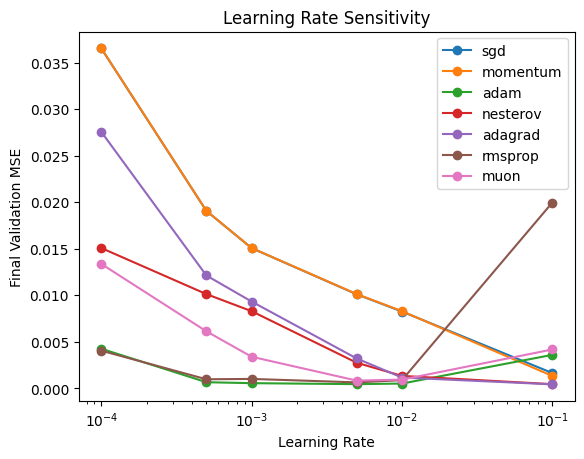

In [ ]:
lr_values = [1e-4, 5e-4,1e-3,5e-3,1e-2,0.1]
lr_results = {}

for opt in optimizers:

  mse_list = []
  for lr in lr_values:
    np.random.seed(42)
    model = MLP(
            layer_sizes,
            activations,
            loss="mse",
            learning_rate=lr,
            batch_size=64,
            optimizer=opt
        )

    history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled, epochs=100)

    val_pred, _ = model.forward(X_val)
    mse = model.loss(y_val_scaled, val_pred[-1])

    mse_list.append(mse)

  lr_results[opt] = mse_list
for opt in lr_results:

    plt.plot(lr_values, lr_results[opt], marker='o', label=opt)

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Final Validation MSE")
plt.title("Learning Rate Sensitivity")
plt.legend()
plt.show()

In [ ]:
best_lr = {}

for opt in optimizers:
    mse_list = lr_results[opt]
    idx = np.argmin(mse_list)
    best_lr[opt] = lr_values[idx]
    print(opt,"best lr:",best_lr[opt])

sgd best lr: 0.1
momentum best lr: 0.1
adam best lr: 0.005
nesterov best lr: 0.1
adagrad best lr: 0.1
rmsprop best lr: 0.005
muon best lr: 0.005


In [ ]:
# function to compute epoch to reach 90% of best validation accuracy

def time_to_90(history):

    val_loss = history["val_loss"]

    best_loss = min(val_loss)          # best validation mse
    target = 1.1 * best_loss         # 90% of best mse

    for epoch, l in enumerate(val_loss):
        if l <= target:
            return epoch             # first epoch reaching target

    return None                      # if never reached

In [ ]:
learning_rates = {
    "sgd": 0.1,
    "momentum": 0.1,
    "adam": 5e-4,
    "nesterov": 0.01,
    "adagrad": 0.01,
    "rmsprop": 5e-4,
    "muon": 5e-3
}
results = {}

for opt in optimizers:

    print("Training with:",opt)
    np.random.seed(42)
    model = MLP(
        layer_sizes,
        activations,
        loss="mse",
        learning_rate=learning_rates[opt],
        batch_size = 64,
        optimizer=opt
    )

    history = model.fit(X_train,y_train_scaled,X_val,y_val_scaled,epochs=100)
    epoch90 = time_to_90(history)
    print("Epoch to reach 90% accuracy:", epoch90)
    results[opt] = history

Training with: sgd
Epoch to reach 90% accuracy: 88
Training with: momentum
Epoch to reach 90% accuracy: 92
Training with: adam
Epoch to reach 90% accuracy: 85
Training with: nesterov
Epoch to reach 90% accuracy: 90
Training with: adagrad
Epoch to reach 90% accuracy: 89
Training with: rmsprop
Epoch to reach 90% accuracy: 85
Training with: muon
Epoch to reach 90% accuracy: 77


Muon reached 90% accuracy the fastest (77 epochs), showing the quickest convergence.

Adam and RMSProp also converged quickly (85 epochs) and achieved stable low training and validation loss due to adaptive learning rates.

SGD, Momentum, Nesterov, and AdaGrad required more epochs (88–92) to reach the same accuracy, indicating slower convergence.

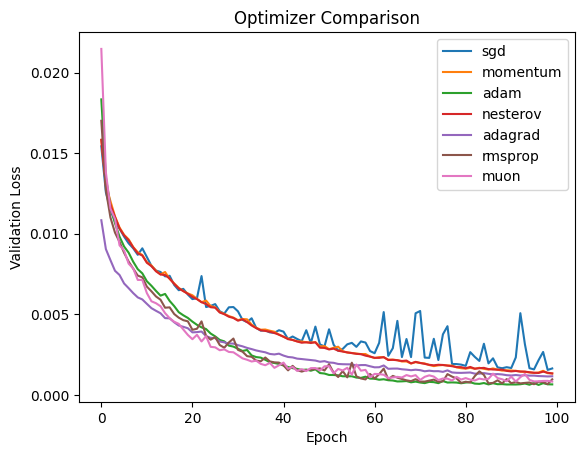

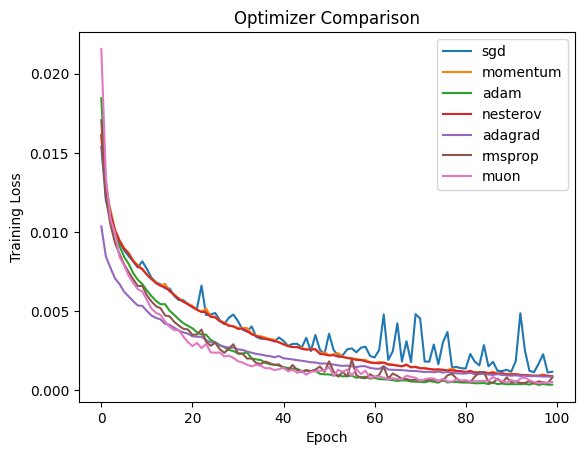

In [ ]:
for opt in results:

    plt.plot(results[opt]["val_loss"],label=opt)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()
for opt in results:

    plt.plot(results[opt]["train_loss"],label=opt)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

Adaptive optimizers (Adam, RMSProp, Muon) converge faster and achieve lower loss, while SGD-based methods require larger learning rates and more epochs to reach similar performance. so we use adam as best optimizer

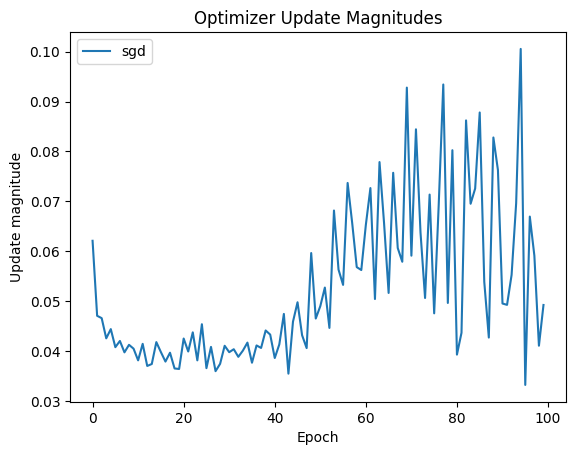

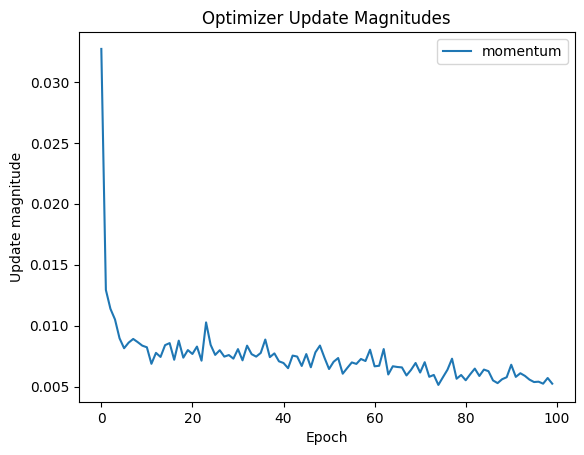

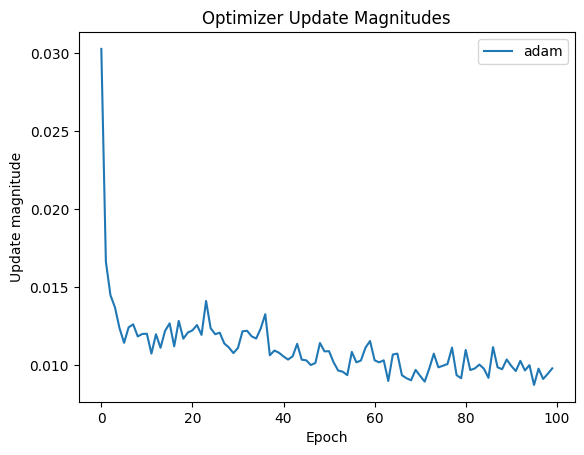

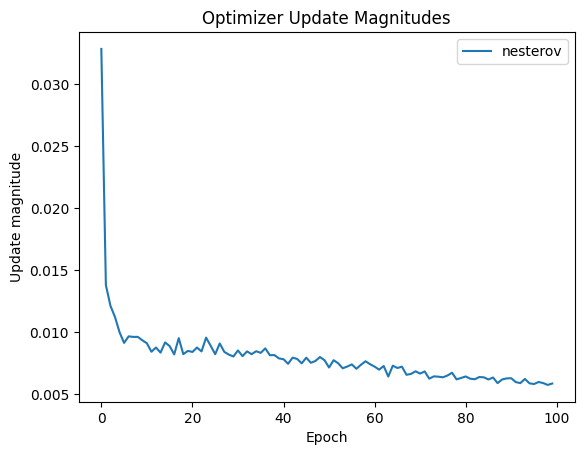

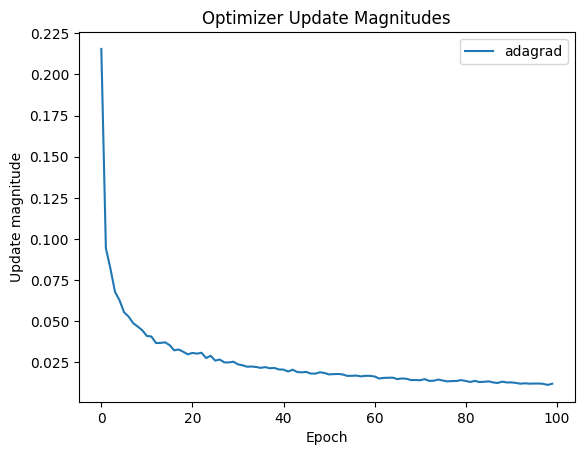

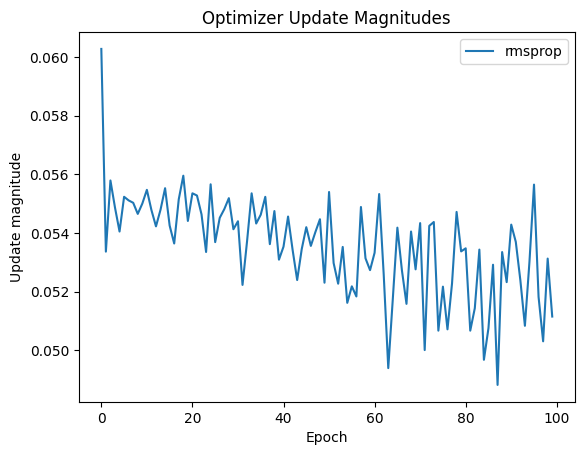

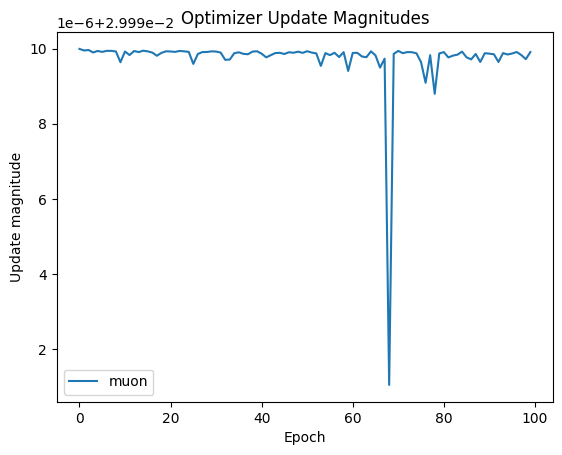

In [ ]:
for opt in results:

    plt.plot(results[opt]["update_mag"], label=opt)
    plt.xlabel("Epoch")
    plt.ylabel("Update magnitude")
    plt.title("Optimizer Update Magnitudes")
    plt.legend()
    plt.show()



SGD shows large and noisy update magnitudes, indicating unstable update directions during training.

Momentum and Nesterov produce smoother and gradually decreasing updates because momentum stabilizes gradient directions.

Adam maintains relatively stable update magnitudes, supporting consistent convergence.

AdaGrad shows rapidly decreasing updates since accumulated gradients reduce the effective learning rate over time.

RMSProp shows noticeable fluctuations (noise) in update magnitudes due to adaptive gradient scaling.

Muon displays unusual behavior with mostly constant updates but occasional sharp drops, indicating irregular update adjustments.

Therefore, the adaptive optimizer is Adam

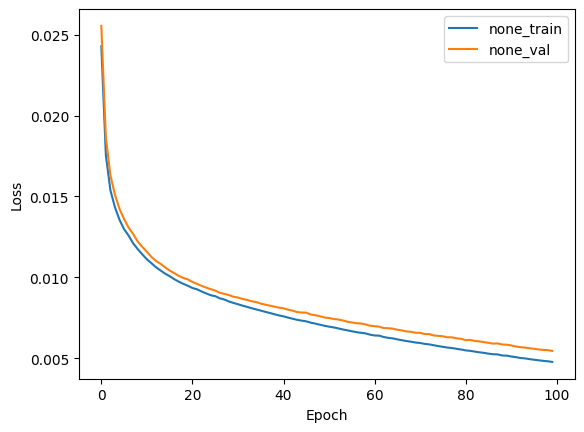

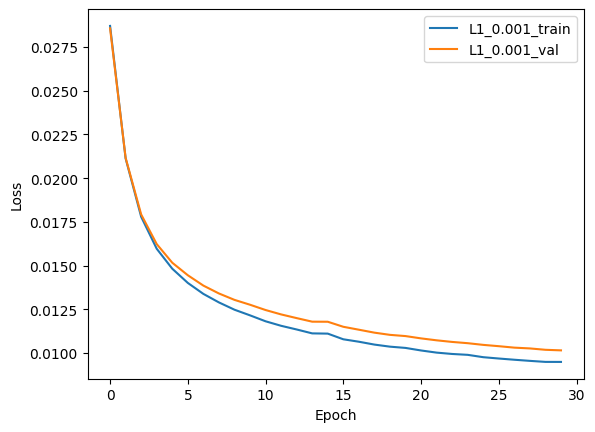

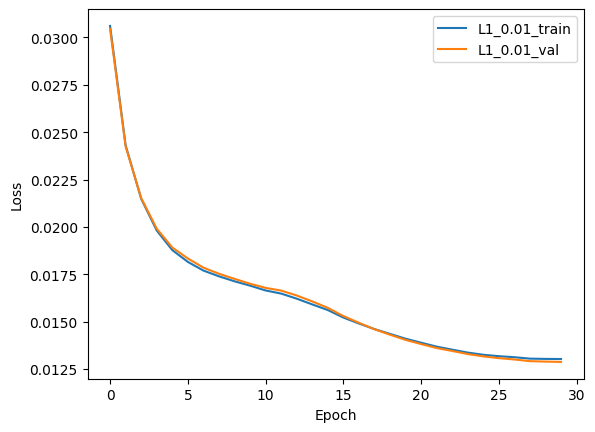

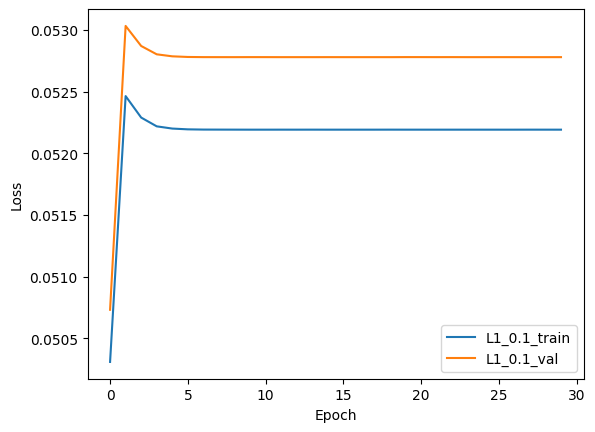

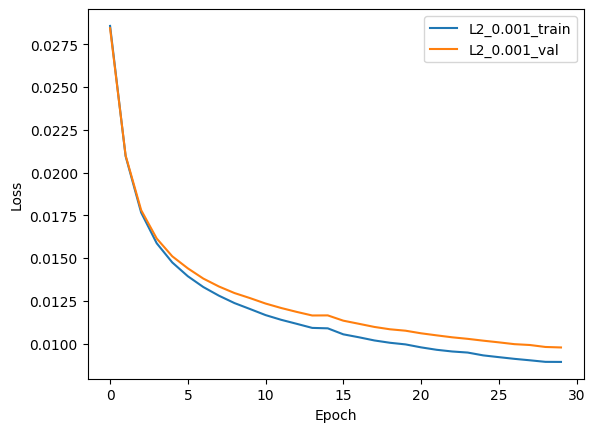

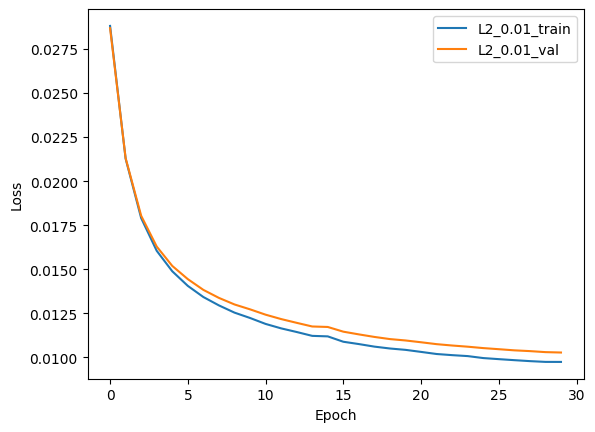

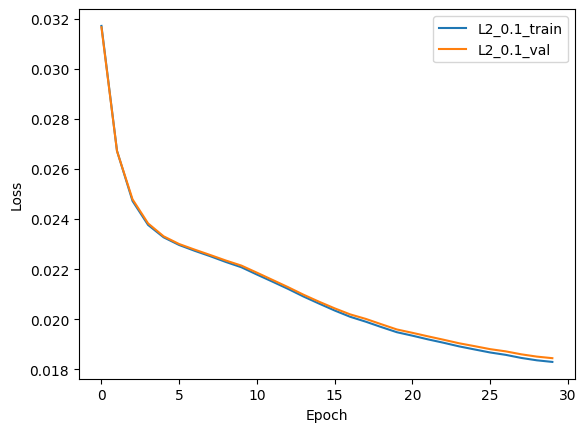

In [ ]:
lambdas = [0.001, 0.01, 0.1]
layer_sizes = [13,64,64,1]
activations = ["relu","relu","sigmoid"]
reg_results = {}
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_val_scaled = (y_val - y_min) / (y_max - y_min)
# No regularization
model = MLP(layer_sizes, activations, loss="mse")
reg_results["none"] = model.fit(X_train, y_train_scaled, X_val, y_val_scaled,epochs = 100)

# L1
for lam in lambdas:
    np.random.seed(42)
    model = MLP(layer_sizes, activations,
                loss="mse",
                regularization="l1",
                lambda_reg=lam)

    reg_results[f"L1_{lam}"] = model.fit(X_train, y_train_scaled, X_val, y_val_scaled,epochs = 30)

# L2
for lam in lambdas:
    np.random.seed(42)
    model = MLP(layer_sizes, activations,
                loss="mse",
                regularization="l2",
                lambda_reg=lam)

    reg_results[f"L2_{lam}"] = model.fit(X_train, y_train_scaled, X_val, y_val_scaled,epochs=30)
for key in reg_results:

    plt.plot(reg_results[key]["train_loss"], label=f"{key}_train")
    plt.plot(reg_results[key]["val_loss"], label=f"{key}_val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

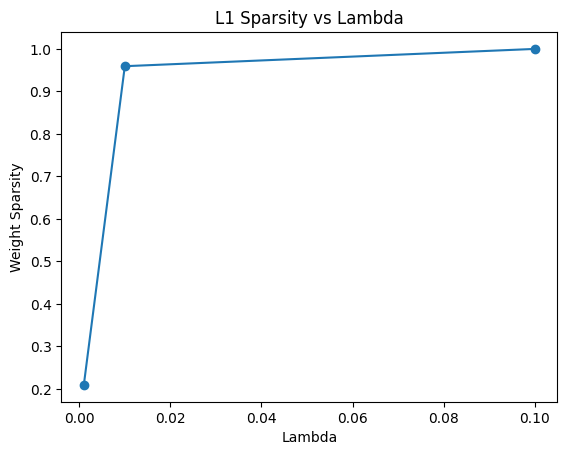

In [ ]:
sparsity = []

for lam in lambdas:

    model = MLP(layer_sizes, activations,
                loss="mse",
                regularization="l1",
                lambda_reg=lam)

    model.fit(X_train, y_train_scaled, X_val, y_val_scaled,epochs=30)

    weights = np.concatenate([w.flatten() for w in model.weights])

    frac = np.mean(np.abs(weights) < 1e-3)

    sparsity.append(frac)
plt.plot(lambdas, sparsity, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Weight Sparsity")
plt.title("L1 Sparsity vs Lambda")
plt.show()

Without regularization, the model achieves the lowest training loss but shows a slightly larger gap between training and validation loss, indicating potential overfitting. Introducing L1 regularization increases the loss slightly but encourages weight sparsity, as many weights become close to zero. The sparsity increases significantly as the regularization parameter
λ increases, although very large values (e.g.
λ=0.1) lead to underfitting and higher loss. L2 regularization penalizes large weights and produces smoother weight updates, which helps reduce overfitting while maintaining stable training. Overall, moderate regularization improves generalization, with L1 promoting sparse models and L2 providing more stable weight control.

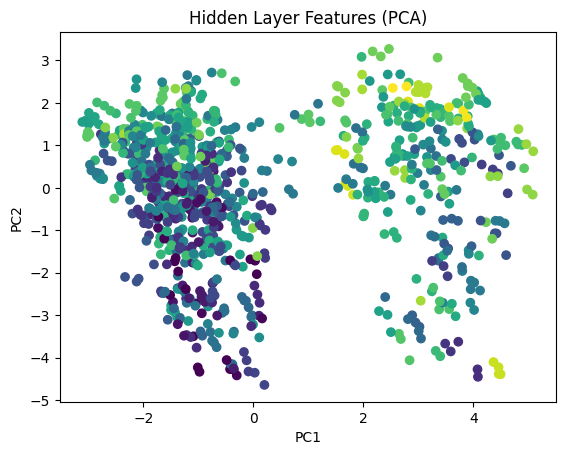

In [ ]:
layer_sizes = [input_dim,64,64,1]
activations = ["relu","relu","sigmoid"]
model = MLP(
            layer_sizes,
            activations,
            loss="mse",
            learning_rate=0.001,
            batch_size=64,
            optimizer="adam"
        )
activations, _ = model.forward(X_val)
hidden = activations[1]   # first hidden layer
# Center the data
X = hidden - np.mean(hidden, axis=0)

# Covariance matrix
cov = np.cov(X, rowvar=False)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov)

# Sort eigenvectors by descending eigenvalues
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

# Take top 2 principal components
W = eigvecs[:, :2]

# Project to 2D
X_pca = X @ W
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_val, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hidden Layer Features (PCA)")
plt.show()

The PCA projection of the hidden layer activations shows how the MLP transforms the input features into a more separable representation. In the 2D PCA plot, the data points form two main clusters along the first principal component (PC1), indicating that the hidden layer has learned a representation where the classes become more distinguishable. Points belonging to different classes (indicated by color) tend to group together within these clusters, showing that the MLP has successfully extracted meaningful nonlinear features. Some overlap is still visible, which is expected due to noise in the dataset and the dimensionality reduction from higher dimensions to two PCA components. Overall, the visualization demonstrates that the hidden layer of the MLP learns structured feature representations that help separate the classes, something a linear model cannot easily achieve.

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_val_scaled = (y_val - y_min) / (y_max - y_min)

In [ ]:
adaline_model = Adaline(learning_rate=0.01, max_iterations=100)
adaline_model.fit(X_train, y_train_scaled.flatten())
adaline_mse_train = adaline_model.score(X_train, y_train_scaled.flatten())
print("Adaline Train MSE:", adaline_mse_train)

Adaline Train MSE: 0.04432423842659619


In [ ]:
import time
import pandas as pd

activation_functions = ["relu","relu","linear"]

# ----- Adaline -----
adaline_model = Adaline(learning_rate=0.01, max_iterations=100)

start = time.time()
adaline_model.fit(X_train, y_train_scaled.flatten())
adaline_time = time.time() - start

adaline_mse_train = adaline_model.score(X_train, y_train_scaled.flatten())
adaline_mse_val = adaline_model.score(X_val, y_val_scaled.flatten())


# ----- MLP -----
start = time.time()

model = MLP(
    layer_sizes,
    activation_functions,   # fixed here
    loss="mse",
    learning_rate=0.01,
    batch_size=64,
    optimizer="adam"
)

history = model.fit(X_train, y_train_scaled, X_val, y_val_scaled,epochs=100)
mlp_time = time.time() - start


# predictions
mlp_pred_train, _ = model.forward(X_train)
mlp_pred_val, _ = model.forward(X_val)

mlp_mse_train = model.loss(y_train_scaled, mlp_pred_train[-1])
mlp_mse_val = model.loss(y_val_scaled, mlp_pred_val[-1])


# comparison table
data = {
    "Model": ["Adaline", "MLP"],
    "Train MSE": [adaline_mse_train, mlp_mse_train],
    "Validation MSE": [adaline_mse_val, mlp_mse_val],
    "Training Time (s)": [adaline_time, mlp_time]
}

comparison_table = pd.DataFrame(data)

print(comparison_table)

     Model  Train MSE  Validation MSE  Training Time (s)
0  Adaline   0.044324        0.044280           0.011839
1      MLP   0.001002        0.001108           4.872916


The comparison shows a clear trade-off between model complexity and computational cost. The MLP achieves significantly lower training and validation MSE than Adaline, indicating that it can model the underlying nonlinear relationships in the data much better. Adaline is a linear model and therefore has limited expressive power, which results in higher error values. However, Adaline trains extremely fast because it involves only a simple linear update rule and very few parameters. In contrast, the MLP requires multiple layers, nonlinear activations, and backpropagation, which increases training time. Despite the longer training time, the much lower MSE of the MLP indicates better predictive performance and generalization, making it the more effective model for this task